## Rubric

Instructions: DELETE this cell before you submit via a `git push` to your repo before deadline. This cell is for your reference only and is not needed in your report. 

 Scoring: Out of 10 points

- Each Developing  => -2 pts
- Each Unsatisfactory/Missing => -4 pts
  - until the score is 0

If students address the detailed feedback in a future checkpoint they will earn these points back






|                                  | **Unsatisfactory**                                                                                                                                                                                                                                                                                                                        | **Developing**                                                                                                                                                                                                       | **Proficient**                                                                                                                                                                                            | **Excellent**                                                                                                                                                                            |
|----------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **EDA relevance**                | EDA is mostly neither relevant to the question nor helpful in figuring out how to address the question. Or the EDA does address the question, but many obviously relevant variables / analyses / figures were not included. | EDA is partly irrelevant/unhelpful. EDA missed one or two obvioulsy relevant analysis (distributions of single variables or relationships between variables) | EDA includes the obviously relevant / helpful variables in addressing the question.                                                              | Thorough EDA fully explored the dataset                                                                                                                 |
| **EDA analysis and description** | Many of the analyses are poor choices (e.g., using means instead of medians for obviously skewed data), or are poorly described in the text, or do not aid understanding the data                                                                                                                                                     | Some of the analyses are poor choices, or are poorly described in the text, or do not aid understanding the data                                                                                                 | All analyses are correct choices. Only one or two have minor issues in the text descriptions supporting them. Mostly they fit well with other elements of the EDA and support understanding the data  | All analyses are correct choices with clear text descriptions supporting them. The figures fit well with the other elements of the EDA, producing a clear understanding of the data. |
| **EDA figures**                  | Many of the figures are poor plot choices (e.g., using a bar plot to represent a time series where it would be better to use a line plot) or have poor aesthetics (including colormap, data point shape/color, axis labels, titles, annotations, text legibility) or do not aid understanding the data                                | Some of the figures are poor plot choices or have poor aesthetics. Some figures do not aid understanding the data                                                                                                | All figures are correct plot choices. Only one or two have minor questionable aesthetic choices. The figures mostly fit well with the other elements of the EDA and support understanding the data    | All figures are correct plot choices with beautiful aesthetics. The figures fit well with the other elements of the EDA, producing a clear understanding of the data.                |





# COGS 108 - EDA Checkpoint

## Authors
Anand Venkatesan: Hypothesis, Data, Background Research, Writing - original draft
Aviraj Singh Khanuja: Data, Hypothesis, Research Question, Writing - original draft 
Martin Gama Jr: Project administration, Background Research, Ethics, Writing - review & editing
Adrian Chow: Ethics, Background research, Writing - review & editing

# Research Question

How do PM₂.₅ and ozone concentrations correlate to respiratory hospital admission rates across U.S counties and which of the two contribute more?


## Background and Prior Work

Air pollution is one of the most significant environmental threats to public health in the United States and globally. In the United States, EPA regulates six criteria pollutants under the National Ambient Air Quality Standards (NAAQS). Among these, fine particulate matter (PM2.5) and ground-level ozone (O3) have been most consistently linked to respiratory morbidity and increased hospital utilization (U.S. EPA, 2024). Despite decades of regulation under the Clean Air Act, respiratory diseases remain a leading cause of hospitalization in the United States, raising the question of how closely air quality tracks with hospital admission patterns.

PM2.5 refers to airborne particles with a diameter of 2.5 micrometers or less. Due to their extremely small size, these particles can bypass the body’s airway defenses and deposit deep in the alveoli (Xing et al., 2016). Once deposited, it triggers a cascade of harmful biological responses, like increasing the production of reactive oxygen species (ROS) in lung tissue, leading to oxidative stress, which can damage the epithelial barrier of the airways, increase susceptibility to respiratory infections, and worsen chronic conditions such as asthma and chronic obstructive pulmonary disease (COPD) (Xing et al., 2016; Li et al., 2022).

Epidemiological evidence strongly supports a positive association between PM₂.₅ exposure and respiratory hospitalizations. Zanobetti et al. (2009) found that a 10 μg/m³ increase in PM₂.₅ across 26 U.S. communities was associated with a 2.07% increase in respiratory admissions, with stronger effects in communities where PM₂.₅ contained more combustion-related components. Dominici et al. (2006) confirmed this pattern across 204 counties using Medicare data, though the association was stronger in eastern U.S. counties than western ones, suggesting the relationship may vary by region.

Ground-level ozone, unlike PM₂.₅, is not emitted directly but forms through photochemical reactions between nitrogen oxides and volatile organic compounds in sunlight (U.S. EPA, 2024). This means ozone concentrations are highly seasonal, peaking in summer and dropping in winter. This is the opposite of PM₂.₅, which tends to be elevated in winter when temperature inversions trap pollutants near the surface (Vu et al., 2022). This seasonal divergence is important because annual averages could mask seasonal spikes.

Biologically, ozone is a potent respiratory irritant. It causes bronchial inflammation, airway hyperresponsiveness, and impaired lung function upon inhalation (Lim et al., 2019). However, while ozone is linked to asthma and COPD exacerbations, its association with broader respiratory hospitalizations has been less consistent across studies than the evidence for PM₂.₅ (Zheng et al., 2021; ALA, 2025).

Most existing studies have examined PM₂.₅ and ozone individually within single cities or regions. This project compares both pollutants across U.S. counties to determine which shows a stronger association with respiratory hospitalizations.

# Hypothesis


Based on our background research, we hypothesize the following:

First, we predict that there is a significant positive association between air pollution concentrations and respiratory hospital admission rates at the county level. This prediction is grounded in the consistent epidemiological findings from multiple large-scale U.S. studies.

Second, we predict that PM2.5 will show a stronger association with respiratory hospital admission rates than ozone when examining annual county-level data. This is because of the seasonal nature of the two pollutants. Ozone formation depends on sunlight, its concentrations peak during summer and negligible during winter. PM2.5, by contrast, poses a year-round risk and is often elevated during winter. Thus, we hypothesize while examining annual county-level averages, ozone’s contribution to be lesser. Furthermore, PM2.5’s mechanism of harm involves deep alveolar deposition and inflammatory responses that can damage multiple organs. Ozone primarily affects the upper airways and bronchial passages.

## Data

### Data overview

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your data checkpoint feedback


In [1]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# the fully processed dataset
df = pd.read_csv("data/01-interim/epa_air_quality_pm25_ozone_2023.csv")

pm25_df = df[df["Parameter Name"] == "PM2.5 - Local Conditions"]

ozone_df = df[df["Parameter Name"] == "Ozone"]
# preview data
df.head()

,county_fips,State Name,County Name,Year,Parameter Name,Sample Duration,Units of Measure,Arithmetic Mean,Observation Count,Observation Percent,Latitude,Longitude
0,1003,Alabama,Baldwin,2023,Ozone,1 HOUR,Parts per million,0.047836,5148,92,30.497478,-87.880258
1,1003,Alabama,Baldwin,2023,Ozone,8-HR RUN AVG BEGIN HOUR,Parts per million,0.043288,5345,91,30.497478,-87.880258
2,1003,Alabama,Baldwin,2023,Ozone,8-HR RUN AVG BEGIN HOUR,Parts per million,0.043288,5345,91,30.497478,-87.880258
3,1003,Alabama,Baldwin,2023,Ozone,8-HR RUN AVG BEGIN HOUR,Parts per million,0.043255,3789,88,30.497478,-87.880258
4,1003,Alabama,Baldwin,2023,PM2.5 - Local Conditions,1 HOUR,Micrograms/cubic meter (LC),7.690417,8150,93,30.497478,-87.880258


### Dataset #1 

Instructions: REPLACE the contents of this cell and the one below with your work, including any updates to recover points lost in your data checkpoint feedback

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32326 entries, 0 to 32325
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   county_fips          32326 non-null  int64  
 1   State Name           32326 non-null  object 
 2   County Name          32326 non-null  object 
 3   Year                 32326 non-null  int64  
 4   Parameter Name       32326 non-null  object 
 5   Sample Duration      32326 non-null  object 
 6   Units of Measure     32326 non-null  object 
 7   Arithmetic Mean      32322 non-null  float64
 8   Observation Count    32326 non-null  int64  
 9   Observation Percent  32326 non-null  int64  
 10  Latitude             32326 non-null  float64
 11  Longitude            32326 non-null  float64
dtypes: float64(3), int64(4), object(5)
memory usage: 3.0+ MB


In [4]:
df.describe()

,county_fips,Year,Arithmetic Mean,Observation Count,Observation Percent,Latitude,Longitude
count,32326.000000,32326.0,32322.000000,32326.000000,32326.000000,32326.000000,32326.000000
mean,28431.096053,2023.0,6.954423,1857.596424,87.179484,38.582015,-91.599738
std,15408.792851,0.0,3.869509,2972.123890,19.944873,5.335803,16.063918
min,1003.000000,2023.0,0.014442,1.000000,0.000000,18.009558,-158.088613
25%,17031.000000,2023.0,5.213605,138.000000,87.000000,35.356615,-99.763424
50%,27139.000000,2023.0,7.997778,321.000000,97.000000,39.464872,-87.274512
75%,40135.000000,2023.0,9.575691,2218.750000,99.000000,41.679867,-80.256944
max,80026.000000,2023.0,28.664706,8759.000000,100.000000,64.845930,-65.618888


In [5]:
# Check missing values
df.isnull().sum().sort_values(ascending=False)

Arithmetic Mean        4
county_fips            0
State Name             0
County Name            0
Year                   0
Parameter Name         0
Sample Duration        0
Units of Measure       0
Observation Count      0
Observation Percent    0
Latitude               0
Longitude              0
dtype: int64

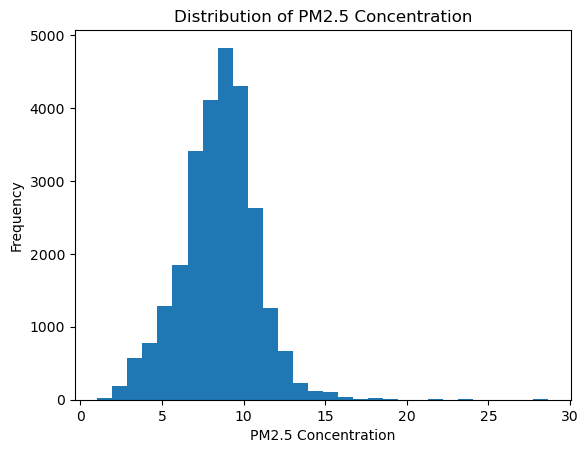

In [6]:
# PM2.5 histogram
plt.hist(pm25_df["Arithmetic Mean"].dropna(), bins=30)

plt.xlabel("PM2.5 Concentration")
plt.ylabel("Frequency")
plt.title("Distribution of PM2.5 Concentration")

plt.show()

The distribution of PM2.5 concentrations appears slightly right-skewed, with most monitoring locations reporting concentrations between approximately 5 and 10 units. However, a smaller number of monitors recorded much higher PM2.5 concentrations, creating a long right tail in the distribution. This suggests that while most counties experience moderate PM2.5 levels, certain areas may experience substantially worse particulate pollution exposure.

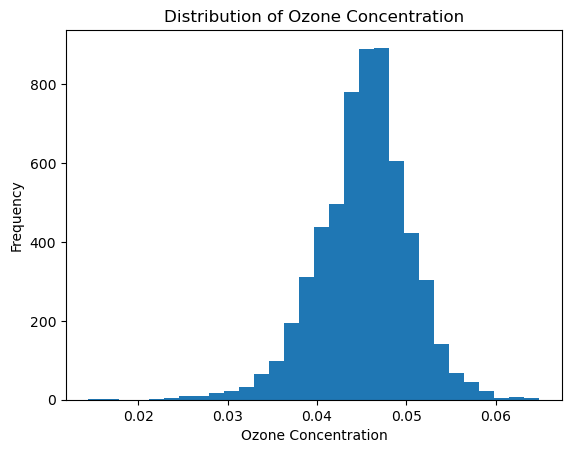

In [7]:
# Ozone histogram
plt.hist(ozone_df["Arithmetic Mean"].dropna(), bins=30)

plt.xlabel("Ozone Concentration")
plt.ylabel("Frequency")
plt.title("Distribution of Ozone Concentration")

plt.show()

The ozone concentration distribution appears more normally distributed and concentrated around a narrower range of values compared to PM2.5 concentrations. Most ozone measurements cluster between approximately 0.04 and 0.05, with fewer extreme outliers. This suggests ozone levels may be more geographically consistent across monitored counties than PM2.5 levels.

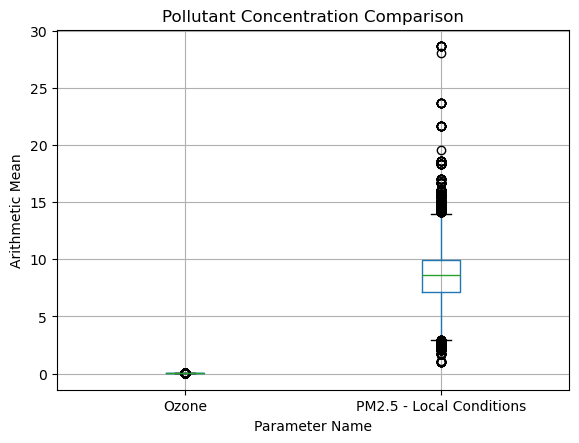

In [8]:
# Boxplot comparison
pollutants = df[df["Parameter Name"].isin(["Ozone", "PM2.5 - Local Conditions"])]

pollutants.boxplot(column="Arithmetic Mean", by="Parameter Name")

plt.ylabel("Arithmetic Mean")
plt.title("Pollutant Concentration Comparison")
plt.suptitle("")

plt.show()

The boxplot comparison highlights substantial differences in the variability of PM2.5 and ozone concentrations. PM2.5 concentrations show a much wider spread and many large value outliers, indicating that some monitoring locations experience significantly elevated particulate pollution levels. In contrast, ozone concentrations vary within a much smaller numerical range. This suggests PM2.5 pollution may differ more dramatically across regions than ozone pollution.

It is important to note that the ozone and PM2.5 are measured in different units and scales, the numerical ranges should not be interpreted as direct comparisons of pollutant severity.

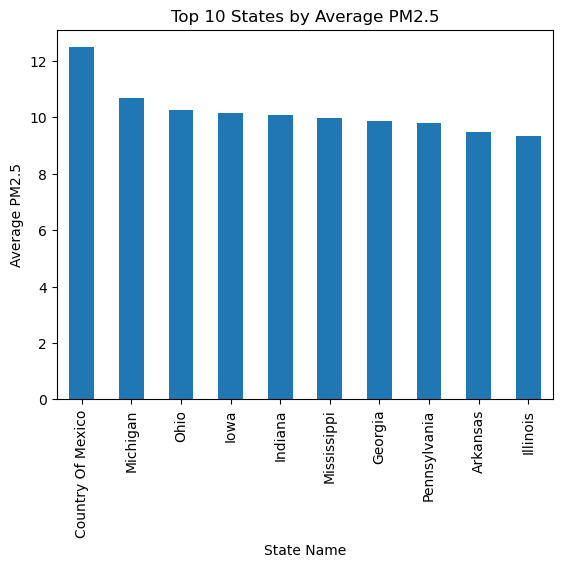

In [9]:
# Top 10 states by average PM2.5
top_states = (
    pm25_df.groupby("State Name")["Arithmetic Mean"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_states.plot(kind="bar")

plt.ylabel("Average PM2.5")
plt.title("Top 10 States by Average PM2.5")

plt.show()

The top 10 states with the highest average PM2.5 concentrations include New Mexico, Michigan, Ohio, Iowa, Indiana, Mississippi, Georgia, Pennsylvania, Arkansas, and Illinois. New Mexico had the highest observed average PM2.5 concentration at approximately 13, while the remaining states ranged between roughly 9 and 10.

The relatively small spread between most states suggests that many states experience somewhat similar average PM2.5 levels, although a few states stand out with noticeably higher concentrations. These differences may reflect variation in industrial activity, transportation density, urbanization, wildfire exposure, agricultural emissions, or regional climate conditions.

The presence of Midwestern and Southern states among the highest PM2.5 averages may indicate the influence of manufacturing activity, fossil fuel usage, and agricultural pollution sources. However, these results should be interpreted cautiously because the EPA dataset is monitor-level rather than population-level. Some states may contain more monitoring stations than others, and counties without monitors are not represented in the dataset.

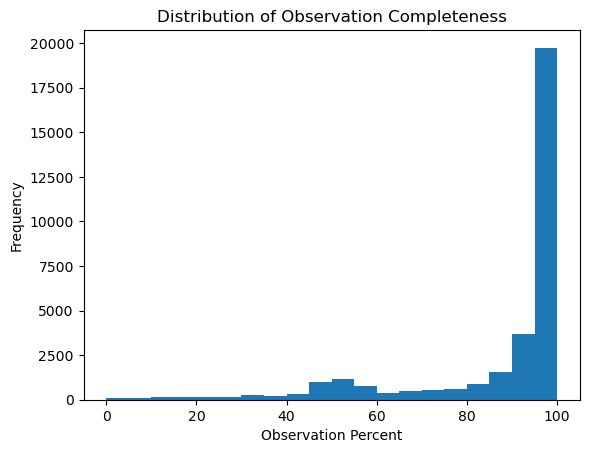

In [10]:
plt.hist(df["Observation Percent"], bins=20)

plt.xlabel("Observation Percent")
plt.ylabel("Frequency")
plt.title("Distribution of Observation Completeness")

plt.show()

The distribution of observation completeness is strongly left-skewed, indicating that most monitoring stations recorded very high percentages of expected observations during the year. This suggests that the majority of annual pollutant averages are based on relatively complete monitoring records, which improves the reliability of the dataset overall.

However, a smaller number of monitoring locations had substantially lower observation percentages, meaning their annual averages were calculated from less complete data. These incomplete observations may introduce additional uncertainty or reduce the reliability of pollutant estimates for certain counties. This limitation is important to consider when interpreting geographic differences in pollution levels.

### Dataset #2
 as above, add any more copies of this that you need to given how many datasets you have

In [12]:
df2 = pd.read_csv("data/01-interim/cdc_places_respiratory_2025.csv", dtype={"county_fips": str})

df2["county_fips"] = df2["county_fips"].str.zfill(5)

asthma_df = df2[df2["Measure"] == "Current asthma among adults"]
copd_df = df2[df2["Measure"] == "Chronic obstructive pulmonary disease among adults"]

df2.head()

,Year,StateAbbr,State Name,County Name,county_fips,TotalPopulation,Measure,Data_Value_Unit,Data_Value_Type,Data_Value,Low_Confidence_Limit,High_Confidence_Limit
0,2023,AR,Arkansas,Fulton,05049,12421,Current asthma among adults,%,Crude prevalence,10.6,9.2,11.9
1,2023,CO,Colorado,Lake,08065,7365,Current asthma among adults,%,Crude prevalence,10.2,9.0,11.6
2,2023,ME,Maine,Hancock,23009,56526,Current asthma among adults,%,Crude prevalence,12.1,10.7,13.5
3,2023,MD,Maryland,Carroll,24013,176639,Current asthma among adults,%,Crude prevalence,10.1,8.9,11.4
4,2023,NE,Nebraska,Thomas,31171,677,Current asthma among adults,%,Crude prevalence,9.0,7.9,10.1


In [13]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11832 entries, 0 to 11831
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Year                   11832 non-null  int64  
 1   StateAbbr              11832 non-null  object 
 2   State Name             11832 non-null  object 
 3   County Name            11828 non-null  object 
 4   county_fips            11832 non-null  object 
 5   TotalPopulation        11832 non-null  int64  
 6   Measure                11832 non-null  object 
 7   Data_Value_Unit        11832 non-null  object 
 8   Data_Value_Type        11832 non-null  object 
 9   Data_Value             11828 non-null  float64
 10  Low_Confidence_Limit   11828 non-null  float64
 11  High_Confidence_Limit  11828 non-null  float64
dtypes: float64(3), int64(2), object(7)
memory usage: 1.1+ MB


In [14]:
df2.describe()

,Year,TotalPopulation,Data_Value,Low_Confidence_Limit,High_Confidence_Limit
count,11832.0,1.183200e+04,11828.000000,11828.000000,11828.000000
mean,2023.0,2.205348e+05,9.194707,7.925812,10.577697
std,0.0,6.164536e+06,2.115438,1.966977,2.284018
min,2023.0,4.300000e+01,3.200000,2.600000,3.900000
25%,2023.0,1.047900e+04,7.500000,6.300000,8.900000
50%,2023.0,2.579950e+04,9.800000,8.500000,11.200000
75%,2023.0,6.946000e+04,10.800000,9.400000,12.200000
max,2023.0,3.349149e+08,17.600000,15.000000,20.600000


In [15]:
df2.isnull().sum().sort_values(ascending=False)

County Name              4
Data_Value               4
Low_Confidence_Limit     4
High_Confidence_Limit    4
Year                     0
StateAbbr                0
State Name               0
county_fips              0
TotalPopulation          0
Measure                  0
Data_Value_Unit          0
Data_Value_Type          0
dtype: int64

The cleaned CDC PLACES respiratory dataset contains county-level estimates for current asthma and COPD among adults. The main outcome variable is Data_Value, which represents the estimated prevalence percentage for each respiratory condition. The dataset also includes confidence interval bounds, county identifiers, state names, and total population. Only a very small number of rows have missing values in the respiratory prevalence fields, so missingness appears limited at this stage.

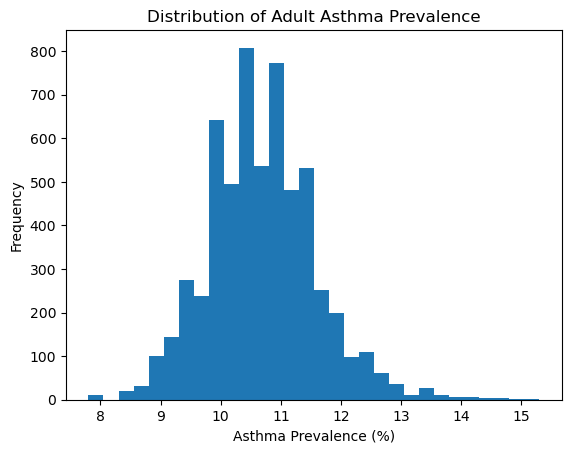

In [17]:
plt.hist(asthma_df["Data_Value"].dropna(), bins=30)

plt.xlabel("Asthma Prevalence (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Adult Asthma Prevalence")

plt.show()

The distribution of adult asthma prevalence is centered around roughly 10% to 11%, meaning most county-level estimates fall in that range. The histogram is slightly right-skewed, with a small number of observations showing higher asthma prevalence around 13% to 15%. This suggests that asthma prevalence is fairly concentrated for most counties, but some counties have noticeably higher estimated asthma burden. These differences may reflect factors such as environmental conditions, healthcare access, demographics, or other county-level health differences.

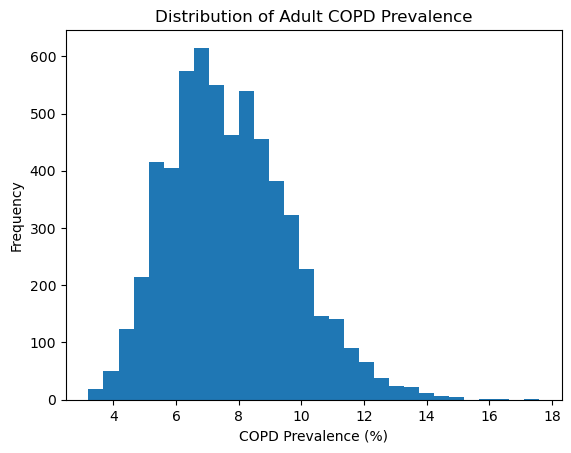

In [18]:
plt.hist(copd_df["Data_Value"].dropna(), bins=30)

plt.xlabel("COPD Prevalence (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Adult COPD Prevalence")

plt.show()

The distribution of adult COPD prevalence is centered around roughly 6% to 9%, with most county-level estimates falling in that range. Compared to the asthma distribution, the COPD distribution appears more right-skewed, with a longer tail extending toward higher prevalence values around 12% to 17%. This suggests that while most counties have moderate estimated COPD prevalence, a smaller number of counties have much higher COPD burden. These differences may reflect county-level factors such as age distribution, smoking rates, socioeconomic conditions, healthcare access, or environmental exposure.

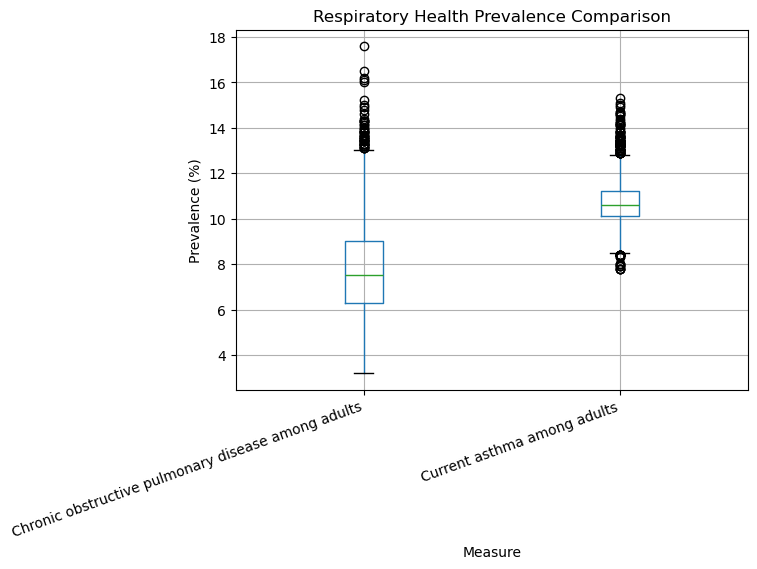

In [22]:
df2.boxplot(column="Data_Value", by="Measure")

plt.ylabel("Prevalence (%)")
plt.title("Respiratory Health Prevalence Comparison")
plt.suptitle("")
plt.xticks(rotation=20, ha="right")

plt.show()

The boxplot compares county-level prevalence estimates for COPD and current asthma among adults. Current asthma has a higher median prevalence, around 10% to 11%, and its values are more tightly clustered. COPD has a lower median prevalence, around 7% to 8%, but shows a wider spread across counties. This suggests that asthma prevalence is generally higher and more consistent across counties, while COPD prevalence varies more substantially by county. Both measures also have high-value outliers, meaning some counties have much higher estimated respiratory disease prevalence than most others.

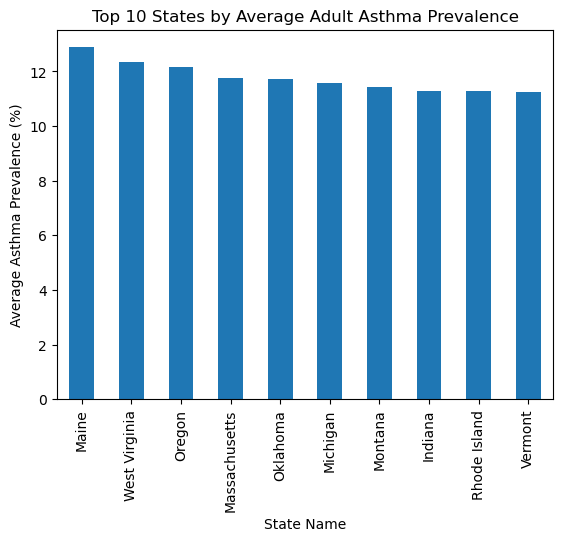

In [20]:
top_asthma_states = (
    asthma_df.groupby("State Name")["Data_Value"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_asthma_states.plot(kind="bar")

plt.ylabel("Average Asthma Prevalence (%)")
plt.title("Top 10 States by Average Adult Asthma Prevalence")

plt.show()

This bar plot shows the 10 states with the highest average adult asthma prevalence across counties in the CDC PLACES respiratory health dataset. Maine has the highest average asthma prevalence at about 13%, followed by West Virginia and Oregon at a little over 12%. The remaining states in the top 10 are mostly between about 11% and 12%.

These results suggest that adult asthma prevalence varies by state, with some states having consistently higher county-level asthma estimates. However, this plot is descriptive only. The differences may be related to many factors, such as environment, demographics, healthcare access, smoking exposure, poverty, or reporting differences. This plot does not show that air pollution directly caused higher asthma prevalence in these states.

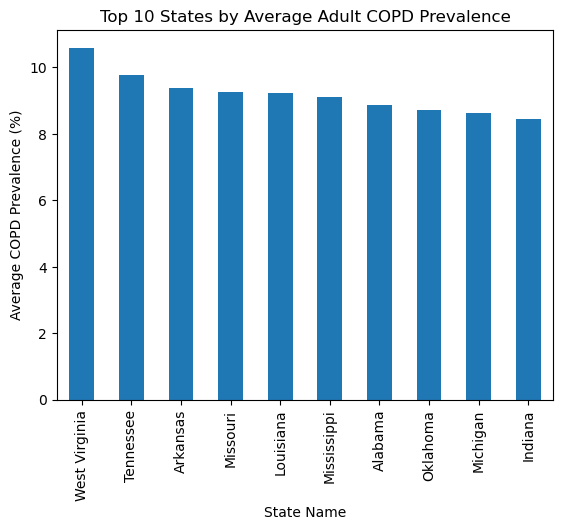

In [21]:
top_copd_states = (
    copd_df.groupby("State Name")["Data_Value"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_copd_states.plot(kind="bar")

plt.ylabel("Average COPD Prevalence (%)")
plt.title("Top 10 States by Average Adult COPD Prevalence")

plt.show()

This bar plot shows the 10 states with the highest average adult COPD prevalence across counties in the CDC PLACES respiratory health dataset. West Virginia has the highest average COPD prevalence at a little above 10%, followed by Tennessee, Arkansas, Missouri, and Louisiana. Most of the top states are in Appalachia or the South, where COPD prevalence appears higher on average.

These results suggest that COPD prevalence varies noticeably by state. However, this plot is only descriptive and does not prove why these states have higher COPD rates. COPD prevalence may be influenced by many factors besides air pollution, including smoking rates, age distribution, poverty, occupational exposure, healthcare access, and other regional health differences. Because of this, these results should be interpreted as county-level patterns rather than causal evidence.

## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`. 



#### Section 1 of EDA - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [ ]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

#### Section 2 of EDA if you need it  - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [ ]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

## Ethics

### A. Data Collection
 - [] **A.1 Informed consent**: Informed consent is not applicable to our question as we are not conducting primary research - using human subjects. We will only be using data already available on the internet.

 - [X] **A.2 Collection bias**: Some identified Biases:

        1)Ozone and PM concentrations will only be rough estimates of their true values. This is because the pollutant concentrations are measured at specific sites across the different counties, whereas people are constantly moving around. To mitigate this variability, we will try to find a reliable average concentration of both pollutants through the use of multiple datasets. 

       2) Hospital admission rates may be affected by socio-economic factors - for instance, patients are more likely to be admitted if they live nearby the sampled hospitals, can afford it and are aware that their health is declining. We will keep in mind the average cost of hospital visits and typical income in the counties we are considering, and adjust the samples so that the counties have similar economies

       3) Confounding variables like smoking habits, other respiratory illnesses and other environmental pollutants may also affect respiratory hospital admission rates. We must ensure that we analyse the data we collect with these confounding variables in mind.

 - [ ] **A.3 Limit PII exposure**: This is irrelevant to our question as we are using secondary data published on the internet by hospitals. It is available for public use and already anonymized.
 - [ ] **A.4 Downstream bias mitigation**: We cannot adjust for factors such as race and gender using publicly available datasets, but we can consider geographical differences (which US counties we want to research).

### B. Data Storage
 - [ ] **B.1 Data security**: This will not be an issue as the data is already publicly available. We will simply be analysing the data.
 - [ ] **B.2 Right to be forgotten**: This will not be an issue, our data consists entirely of county-level aggregates, no individual patients or residents can be identified.
 - [X] **B.3 Data retention plan**:  We will retain all datasets and clean files, as well as analysis code throughout the duration of the research project to ensure reproducibility. We will also frequently update the datasets used as it changes to match the data available on public sites.


### C. Analysis
 - [X] **C.1 Missing perspectives**: Counties without EPA air quality monitors are invisible in our analysis. These tend to be rural, lower-income, and less populated areas that may still face significant pollution. Our findings would reflect monitored, often urban counties. 
 - [X] **C.2 Dataset bias**: Hospital admission rates not only indicate illness but also access. Counties with lesser hospitals or higher insurance rates will show lesser admission rates even if residents are affected by pollution. This is also true for counties with lower median income, which leads to lesser healthcare access.
    
 - [X] **C.3 Honest representation**: Since we have identified various confounding socioeconomic and demographic variables, we will clearly state that observed correlations between air quality and hospitalizations do not prove that pollution directly caused the admissions. Hence, we will report the strength of the associations without implying any causation.
 - [ ] **C.4 Privacy in analysis**: Privacy is not a concern because individual identifiers are not revealed in the publicly available datasets, making it difficult to trace the data back to an individual person. All the data collected is aggregated and averaged.
 - [X] **C.5 Auditability**: We will document all data sources with URLs, all cleaning and merging steps, and all analytical decisions so that our process can be reviewed and replicated by our TA or other researchers.
### D. Modeling
 - [X] **D.1 Proxy discrimination**: County-level pollution concentrations can act as proxies for socioeconomic status because high-pollution counties are often low-income and disproportionately nonwhite. Any association we find between pollution and hospitalizations could represent poverty and structural inequality rather than pollution's biological effects alone.
 - [X] **D.2 Fairness across groups**: As the region of the US is a proxy variable for median income and can affect hospital admission rates, we will try and compare regions with similar median incomes and poverty rates with each other to ensure fairness in assessing how pollutant concentrations affect hospital admissions.
 - [X] **D.3 Metric selection**: We will use correlation coefficients like R^2 and p-values to determine the strength of the relationships between pollutant concentrations and respiratory hospital admissions as well as the individual significance of ozone and PM.
 - [X] **D.4 Explainability**: Our project will rely on straightforward and simple correlation coefficients and document all the coding processes, arriving at a systematic conclusion to ensure reader understandability.

 - [X] **D.5 Communicate limitations**: We will explicitly state that correlation does not equal causation, that county-level patterns cannot be applied to individual risk, and that our results are limited to counties with available monitoring data.
### E. Deployment
 - [X] **E.1 Monitoring and evaluation**: This is an academic project and will not be deployed as a tool or policy recommendation. However, this research could be used to inform public policy on access to healthcare, poverty and pollution management. Findings should be revisited as new air quality and hospitalization data becomes available, since pollution patterns and healthcare infrastructure change over time. 
 - [X] **E.2 Redress**: If research like ours were used to label counties as "high risk," affected counties should have a mechanism or review system to contest that as our data has known gaps and may not accurately represent all counties. 
 - [X] **E.3 Roll back**: If the underlying data or methodology is later found to be flawed, any conclusions or policy decisions based on the analysis should be reversible. This will be done by saving all our analysis code and implementing version control.
 - [X] **E.4 Unintended use**: The most significant concern is that insurance companies could use county-level pollution-hospitalization associations to raise health insurance premiums for residents of high-pollution areas. This would disproportionately penalize low-income communities and communities of color who already bear the greatest pollution burden and may lack the economic means to relocate. Safeguards should prevent this type of discriminatory application.

## Team Expectations 

**Communication:** We will use Discord as our primary communication platform. All members are expected to respond to messages within 24 hours. We will meet weekly on Tuesday afternoon at geisel to check in on progress.

**Tone & Respect:** We agree to communicate in a "blunt but polite" manner. Criticism should be directed at ideas, not people, and framed constructively (e.g., "I think X could be improved because Y, what does everyone think?"). We will assume good intentions behind all feedback.

**Decision Making:** Decisions will be made by majority vote. If a decision is time-sensitive and a member is unresponsive for more than 24 hours, the remaining members may proceed and will update the absent member afterward.

**Task Distribution:** Tasks will be divided based on each member's strengths and interests, but every member is expected to contribute to code, writing, and editing at some point during the project. We will track tasks and deadlines using a shared Google Doc / GitHub Issues / Trello board.

**Deadlines & Accountability:** Each member will complete their assigned tasks by the agreed-upon internal deadlines. If someone is struggling or falling behind, they should notify the group as soon as possible, at least 48 hours before the deadline, so the team can redistribute work.

**Equal Contribution:** All members are expected to contribute equally across the project overall. No one person should be responsible for all of the coding, all of the writing, or all of the editing.

**Conflict Resolution:** If a conflict arises, we will address it directly and respectfully within the team first. If a member is consistently not meeting expectations, we will follow the COGS108 policy of notifying them in writing with specific improvements needed within one week, and escalate to the professor if there is no change.

## Project Timeline Proposal


**June 3, 2026 — 6:30 PM**
Completed Before Meeting: Finalize analysis outputs. Draft conclusion, discussion, and limitations.
Discuss at Meeting: Review the full notebook draft and identify missing sections. Should have rough outline of final project by then. 

**June 9, 2026 — 7:00 PM**
Completed Before Meeting: Complete final edits and quality checks.
Discuss at Meeting: Confirm submission readiness and verify citations/reproducibility.

**June 10, 2026 — Before Deadline**
Completed Before Meeting: Submit Final Project and group surveys.
Discuss at Meeting: Final project finialization.